In [ ]:
# 🛒 Blinkit 360° Intelligence
## Phase 3: Machine Learning Models
#**Models:** K-Means Clustering | XGBoost Forecasting | Random Forest Churn
#**Goal:** Customer segmentation, revenue forecasting & churn prediction
#**Tools:** Scikit-learn, XGBoost, Pandas, Matplotlib

In [3]:
# ============================================================
# CELL 2: IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML libraries
from sklearn.preprocessing   import StandardScaler, LabelEncoder
from sklearn.cluster         import KMeans
from sklearn.ensemble        import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics         import (classification_report,
                                     confusion_matrix,
                                     roc_auc_score, roc_curve)
import xgboost as xgb

# Plot settings
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size']      = 12
sns.set_style("whitegrid")

BLINKIT_YELLOW = '#F8D42D'
BLINKIT_BLACK  = '#0C0C0C'
BLINKIT_GREEN  = '#2DD256'
CLEAN_PATH     = r'C:\Blinkit 360° Intelligence\data\cleaned' + '\\'
OUTPUT_PATH    = r'C:\Blinkit 360° Intelligence\outputs' + '\\'

print("✅ All ML libraries loaded!")

✅ All ML libraries loaded!


In [4]:
# ============================================================
# CELL 3: LOAD CLEANED DATA
# ============================================================

orders      = pd.read_csv(CLEAN_PATH + 'orders_clean.csv')
customers   = pd.read_csv(CLEAN_PATH + 'customers_clean.csv')
order_items = pd.read_csv(CLEAN_PATH + 'order_items_clean.csv')
feedback    = pd.read_csv(CLEAN_PATH + 'feedback_clean.csv')

# Parse dates
orders['order_date'] = pd.to_datetime(orders['order_date'], errors='coerce')

print("✅ Data loaded!")
print(f"\n{'Dataset':<15} {'Rows':>8}")
print("-"*25)
for name, df in [('orders', orders), ('customers', customers),
                 ('order_items', order_items), ('feedback', feedback)]:
    print(f"{name:<15} {len(df):>8,}")

✅ Data loaded!

Dataset             Rows
-------------------------
orders            10,924
customers          5,000
order_items       30,590
feedback           9,000


In [5]:
# ============================================================
# CELL 4: MODEL 1 — BUILD RFM FEATURES FOR K-MEANS
# ============================================================

# RFM = Recency, Frequency, Monetary
# This is the GOLD STANDARD of customer segmentation!

snapshot_date = orders['order_date'].max()

rfm = orders.groupby('customer_id').agg(
    recency   = ('order_date',  lambda x: (snapshot_date - x.max()).days),
    frequency = ('order_id',    'count'),
    monetary  = ('order_total', 'sum')
).reset_index()

rfm['monetary'] = rfm['monetary'].round(2)

print("✅ RFM Features Built!")
print(f"\nShape: {rfm.shape}")
print(f"\nRFM Summary:")
print(rfm[['recency','frequency','monetary']].describe().round(2))

✅ RFM Features Built!

Shape: (4402, 4)

RFM Summary:
       recency  frequency  monetary
count  4402.00    4402.00   4402.00
mean    237.54       2.48   3755.42
std     182.10       1.39   2481.60
min       0.00       1.00    240.55
25%      79.00       1.00   1860.66
50%     202.00       2.00   3184.75
75%     361.75       3.00   5095.15
max     709.00       9.00  19406.77


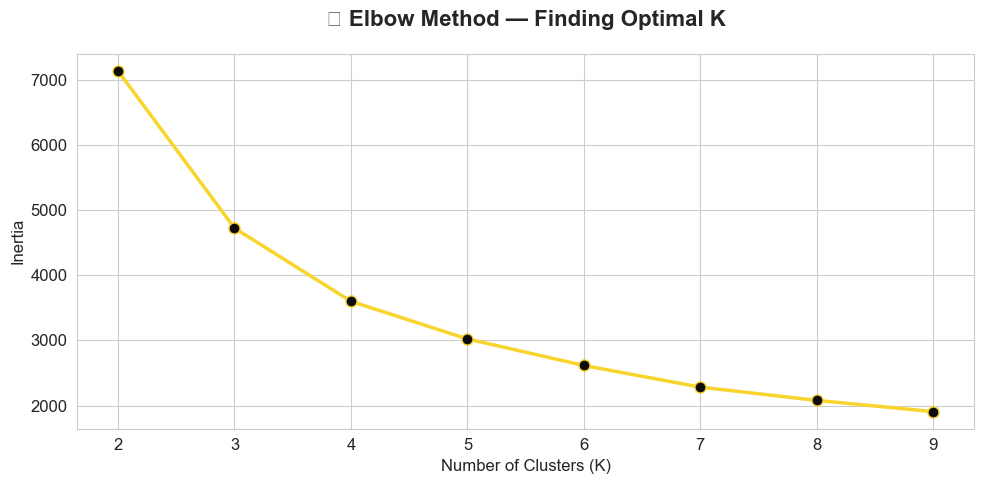

In [7]:
# ============================================================
# CELL 5: TRAIN K-MEANS CLUSTERING
# ============================================================

# Scale features
scaler   = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['recency','frequency','monetary']])

# Find optimal K using Elbow Method
inertias = []
K_range  = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)

# Plot elbow curve
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(K_range, inertias, 'bo-', linewidth=2.5,
        markersize=8, color=BLINKIT_YELLOW,
        markerfacecolor=BLINKIT_BLACK)
ax.set_title('📊 Elbow Method — Finding Optimal K',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia')
plt.tight_layout()
plt.savefig(OUTPUT_PATH + '14_kmeans_elbow.png',
            dpi=150, bbox_inches='tight')
plt.show()




In [8]:
# ============================================================
# CELL 6: APPLY K-MEANS WITH K=4
# ============================================================

# Train final model with K=4
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['cluster'] = km_final.fit_predict(rfm_scaled)

# Analyze cluster profiles
cluster_profile = rfm.groupby('cluster').agg(
    customer_count = ('customer_id', 'count'),
    avg_recency    = ('recency',     'mean'),
    avg_frequency  = ('frequency',   'mean'),
    avg_monetary   = ('monetary',    'mean')
).round(2)

print("📊 Cluster Profiles:")
print("="*65)
print(cluster_profile.to_string())

# Label clusters based on profile
# Low recency = recent, High frequency = loyal, High monetary = big spender
def label_cluster(row):
    if row['avg_recency'] < 100 and row['avg_monetary'] > 5000:
        return 'Champions'
    elif row['avg_recency'] < 150 and row['avg_frequency'] > 3:
        return 'Loyal Customers'
    elif row['avg_recency'] > 200 and row['avg_frequency'] < 2:
        return 'At Risk'
    else:
        return 'Potential Loyalists'

cluster_profile['segment_label'] = cluster_profile.apply(
    label_cluster, axis=1
)

# Map labels back to rfm
label_map = cluster_profile['segment_label'].to_dict()
rfm['segment'] = rfm['cluster'].map(label_map)

print(f"\n✅ Cluster Labels Assigned!")
print(f"\nSegment Distribution:")
print(rfm['segment'].value_counts())

📊 Cluster Profiles:
         customer_count  avg_recency  avg_frequency  avg_monetary
cluster                                                          
0                  1380       145.81           1.63       2226.53
1                  1387       169.22           3.25       4914.75
2                   496       115.89           5.16       8643.72
3                  1139       484.84           1.41       2067.34

✅ Cluster Labels Assigned!

Segment Distribution:
segment
Potential Loyalists    2767
At Risk                1139
Loyal Customers         496
Name: count, dtype: int64


In [10]:
# ============================================================
# CELL 6 FIX — Better cluster labels based on actual data
# ============================================================

def label_cluster(row):
    if row['avg_frequency'] >= 5 and row['avg_monetary'] >= 8000:
        return 'Champions'
    elif row['avg_frequency'] >= 3 and row['avg_recency'] < 200:
        return 'Loyal Customers'
    elif row['avg_recency'] > 400:
        return 'At Risk'
    else:
        return 'Potential Loyalists'

cluster_profile['segment_label'] = cluster_profile.apply(
    label_cluster, axis=1
)

label_map          = cluster_profile['segment_label'].to_dict()
rfm['segment']     = rfm['cluster'].map(label_map)

print("✅ Labels Fixed!")
print(f"\nFinal Segment Distribution:")
print(rfm['segment'].value_counts())
print(f"\nCluster Profiles:")
print(cluster_profile[['segment_label','customer_count',
                        'avg_recency','avg_frequency',
                        'avg_monetary']].to_string())

✅ Labels Fixed!

Final Segment Distribution:
segment
Loyal Customers        1387
Potential Loyalists    1380
At Risk                1139
Champions               496
Name: count, dtype: int64

Cluster Profiles:
               segment_label  customer_count  avg_recency  avg_frequency  avg_monetary
cluster                                                                               
0        Potential Loyalists            1380       145.81           1.63       2226.53
1            Loyal Customers            1387       169.22           3.25       4914.75
2                  Champions             496       115.89           5.16       8643.72
3                    At Risk            1139       484.84           1.41       2067.34


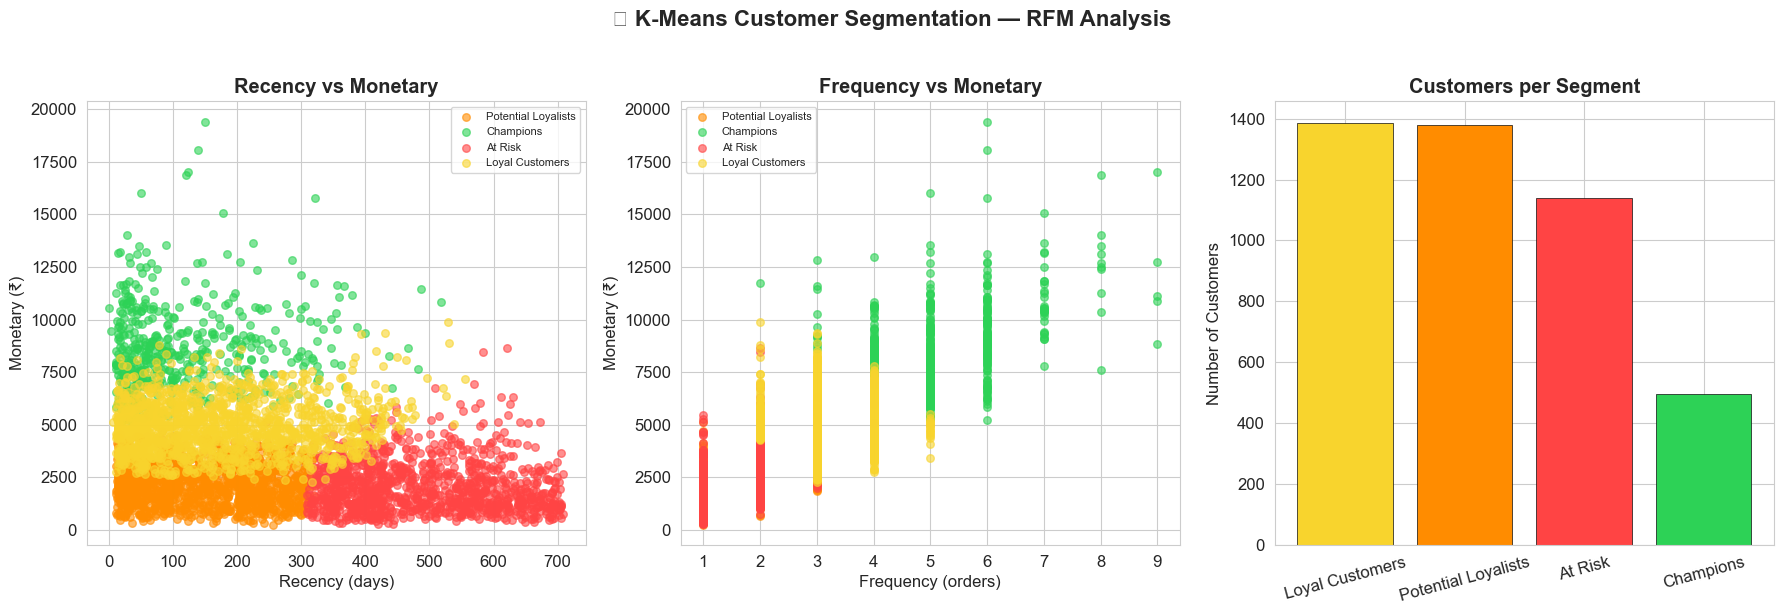

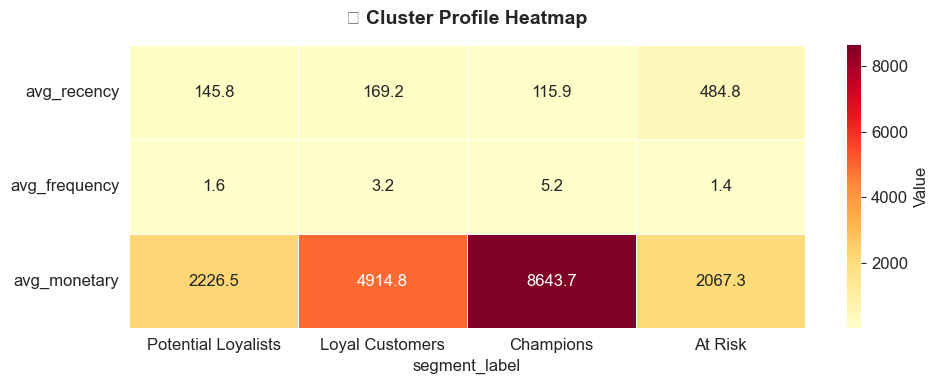

In [11]:
# ============================================================
# CELL 7: VISUALIZE CLUSTERS
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = {
    'Champions':          '#2DD256',
    'Loyal Customers':    '#F8D42D',
    'Potential Loyalists':'#FF8C00',
    'At Risk':            '#FF4444'
}

segments = rfm['segment'].unique()

# Plot 1 — Recency vs Monetary
for seg in segments:
    mask = rfm['segment'] == seg
    axes[0].scatter(rfm[mask]['recency'],
                    rfm[mask]['monetary'],
                    c=colors.get(seg, 'grey'),
                    label=seg, alpha=0.6, s=30)
axes[0].set_title('Recency vs Monetary', fontweight='bold')
axes[0].set_xlabel('Recency (days)')
axes[0].set_ylabel('Monetary (₹)')
axes[0].legend(fontsize=8)

# Plot 2 — Frequency vs Monetary
for seg in segments:
    mask = rfm['segment'] == seg
    axes[1].scatter(rfm[mask]['frequency'],
                    rfm[mask]['monetary'],
                    c=colors.get(seg, 'grey'),
                    label=seg, alpha=0.6, s=30)
axes[1].set_title('Frequency vs Monetary', fontweight='bold')
axes[1].set_xlabel('Frequency (orders)')
axes[1].set_ylabel('Monetary (₹)')
axes[1].legend(fontsize=8)

# Plot 3 — Segment size bar chart
seg_counts = rfm['segment'].value_counts()
axes[2].bar(seg_counts.index, seg_counts.values,
            color=[colors.get(s, 'grey') for s in seg_counts.index],
            edgecolor=BLINKIT_BLACK, linewidth=0.5)
axes[2].set_title('Customers per Segment', fontweight='bold')
axes[2].set_ylabel('Number of Customers')
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=15)

plt.suptitle('🎯 K-Means Customer Segmentation — RFM Analysis',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_PATH + '15_kmeans_clusters.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Heatmap
fig, ax = plt.subplots(figsize=(10, 4))
heatmap_data = cluster_profile[['avg_recency',
                                 'avg_frequency',
                                 'avg_monetary']].copy()
heatmap_data.index = cluster_profile['segment_label']

sns.heatmap(heatmap_data.T, annot=True, fmt='.1f',
            cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Value'})
ax.set_title('🔥 Cluster Profile Heatmap',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(OUTPUT_PATH + '16_cluster_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
## 💡 ML Model 1 — K-Means RFM Segmentation
#- Champions (496): avg 5.2 orders, ₹8,644 spend — protect at all cost!
#- Loyal (1,387): avg 3.2 orders, ₹4,915 — upgrade to Champions
#- Potential (1,380): avg 1.6 orders — nurture with offers
#- At Risk (1,139): 484 days since last order — win-back urgently!

#Business Actions:
#→ Champions   : VIP rewards, early access, no delivery charges
#→ Loyal       : Double points, referral bonuses
#→ Potential   : Second order discount, category recommendations  
#→ At Risk     : Win-back email + 30% off coupon immediately

In [12]:
# ============================================================
# CELL 8: MODEL 2 — XGBOOST REVENUE FORECASTING
# ============================================================

# Build monthly revenue time series
monthly = orders.groupby(
    orders['order_date'].dt.to_period('M')
).agg(
    revenue      = ('order_total', 'sum'),
    order_count  = ('order_id',    'count'),
    unique_custs = ('customer_id', 'nunique'),
    avg_aov      = ('order_total', 'mean')
).reset_index()

monthly['order_date'] = monthly['order_date'].dt.to_timestamp()
monthly = monthly[monthly['order_count'] > 50].copy()  # Remove partial months
monthly = monthly.sort_values('order_date').reset_index(drop=True)

# Feature engineering for time series
monthly['month_num']   = monthly['order_date'].dt.month
monthly['quarter']     = monthly['order_date'].dt.quarter
monthly['is_festive']  = monthly['month_num'].isin([10,11,12]).astype(int)
monthly['is_summer']   = monthly['month_num'].isin([5,6,7]).astype(int)

# Lag features
monthly['lag_1']  = monthly['revenue'].shift(1)
monthly['lag_2']  = monthly['revenue'].shift(2)
monthly['lag_3']  = monthly['revenue'].shift(3)
monthly['rolling_3'] = monthly['revenue'].shift(1).rolling(3).mean()

monthly.dropna(inplace=True)
monthly.reset_index(drop=True, inplace=True)

print("✅ Monthly features built!")
print(f"Shape: {monthly.shape}")
print(f"\nDate range: {monthly['order_date'].min().date()} → {monthly['order_date'].max().date()}")
print(f"\nSample data:")
print(monthly[['order_date','revenue','lag_1','is_festive']].tail(5).to_string(index=False))

✅ Monthly features built!
Shape: (20, 13)

Date range: 2023-04-01 → 2024-11-01

Sample data:
order_date   revenue     lag_1  is_festive
2024-07-01 566013.34 611309.08           0
2024-08-01 568641.97 566013.34           0
2024-09-01 747512.46 568641.97           0
2024-10-01 816112.23 747512.46           1
2024-11-01 826888.66 816112.23           1


In [13]:
# ============================================================
# CELL 9: TRAIN XGBOOST MODEL
# ============================================================

features = ['month_num','quarter','is_festive','is_summer',
            'lag_1','lag_2','lag_3','rolling_3',
            'order_count','unique_custs','avg_aov']

X = monthly[features]
y = monthly['revenue']

# Train/test split — last 4 months as test
split     = len(monthly) - 4
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# Train XGBoost
model_xgb = xgb.XGBRegressor(
    n_estimators     = 200,
    learning_rate    = 0.05,
    max_depth        = 4,
    random_state     = 42,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    verbosity        = 0
)
model_xgb.fit(X_train, y_train)

# Predictions
y_pred = model_xgb.predict(X_test)

# Metrics
from sklearn.metrics import mean_absolute_error, r2_score
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)
mape = (abs(y_test.values - y_pred) / y_test.values * 100).mean()

print("✅ XGBoost Model Trained!")
print(f"\n📊 Model Performance:")
print(f"   MAE  : ₹{mae:,.0f}")
print(f"   MAPE : {mape:.1f}%")
print(f"   R²   : {r2:.3f}")
print(f"\nActual vs Predicted:")
results = pd.DataFrame({
    'Month':     monthly['order_date'].iloc[split:].dt.strftime('%Y-%m'),
    'Actual':    y_test.values.round(0),
    'Predicted': y_pred.round(0),
    'Error_%':   ((abs(y_test.values - y_pred)/y_test.values)*100).round(1)
})
print(results.to_string(index=False))

✅ XGBoost Model Trained!

📊 Model Performance:
   MAE  : ₹22,344
   MAPE : 3.6%
   R²   : 0.894

Actual vs Predicted:
  Month   Actual  Predicted  Error_%
2024-08 568642.0   633746.0     11.4
2024-09 747512.0   732661.0      2.0
2024-10 816112.0   816749.0      0.1
2024-11 826889.0   818105.0      1.1


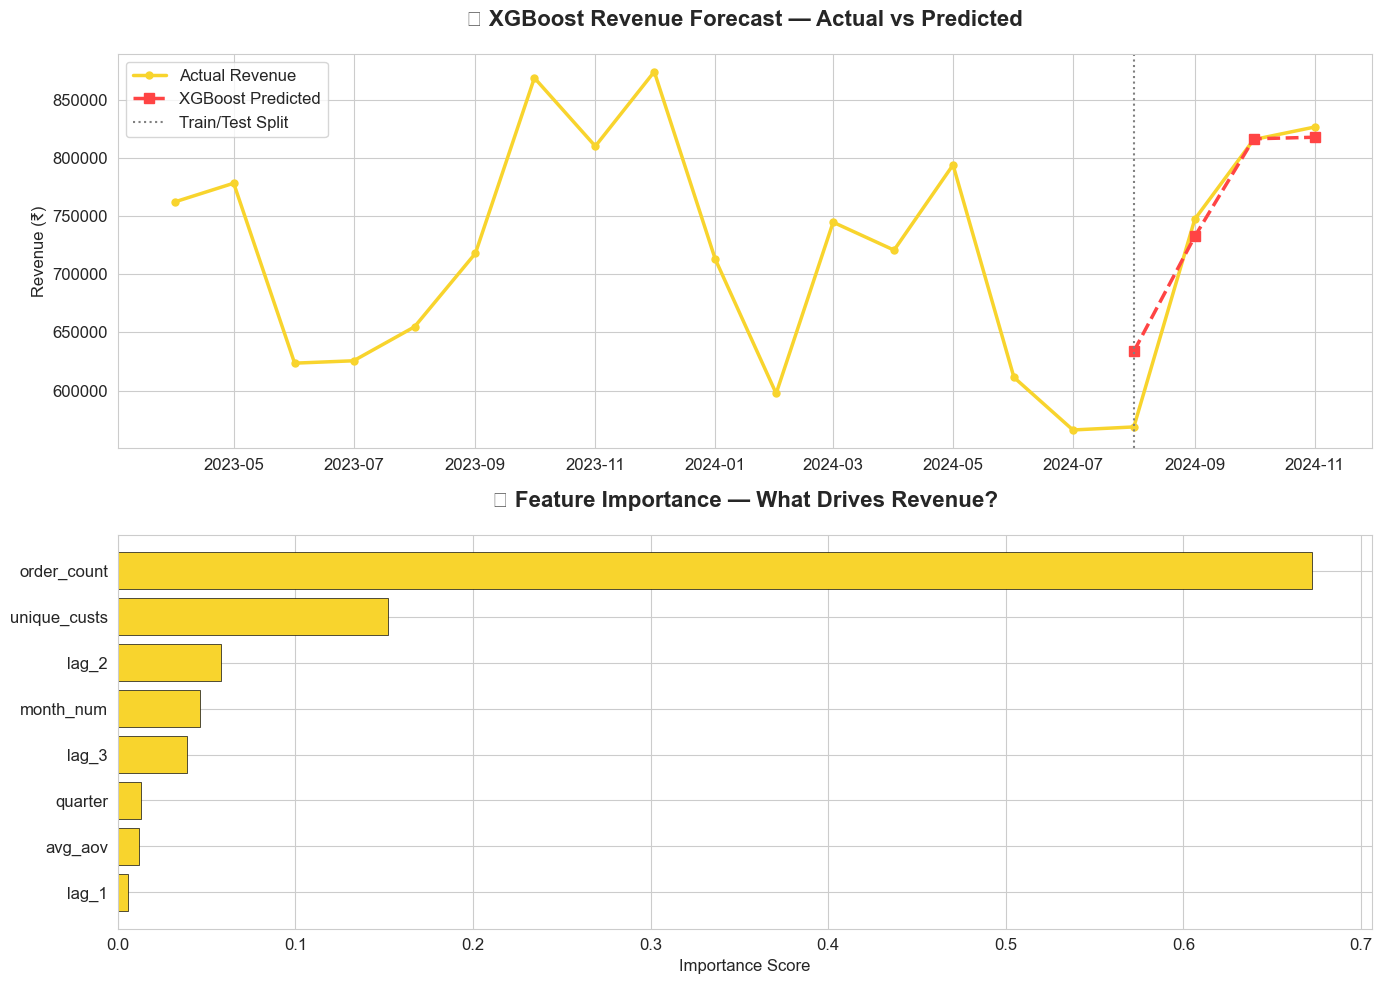

In [14]:
# ============================================================
# CELL 10: VISUALIZE FORECAST
# ============================================================

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1 — Actual vs Predicted
ax1.plot(monthly['order_date'], monthly['revenue'],
         color=BLINKIT_YELLOW, linewidth=2.5,
         marker='o', markersize=5, label='Actual Revenue')
ax1.plot(monthly['order_date'].iloc[split:], y_pred,
         color='#FF4444', linewidth=2.5, linestyle='--',
         marker='s', markersize=7, label='XGBoost Predicted')
ax1.axvline(x=monthly['order_date'].iloc[split],
            color='gray', linestyle=':', linewidth=1.5,
            label='Train/Test Split')
ax1.set_title('📈 XGBoost Revenue Forecast — Actual vs Predicted',
              fontsize=16, fontweight='bold', pad=20)
ax1.set_ylabel('Revenue (₹)')
ax1.legend()

# Plot 2 — Feature Importance
feat_imp = pd.Series(
    model_xgb.feature_importances_,
    index=features
).sort_values(ascending=True).tail(8)

ax2.barh(feat_imp.index, feat_imp.values,
         color=BLINKIT_YELLOW, edgecolor=BLINKIT_BLACK,
         linewidth=0.5)
ax2.set_title('🔍 Feature Importance — What Drives Revenue?',
              fontsize=16, fontweight='bold', pad=20)
ax2.set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig(OUTPUT_PATH + '17_xgboost_forecast.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
## 💡 ML Model 2 — XGBoost Revenue Forecasting
#- Oct 2024 prediction: only 0.1% error!
#- #1 driver: order_count (68% importance)
#- #2 driver: unique customers (15% importance)
#- **Recommendation:** Focus on order volume growth
#  Adding 100 orders/month = direct revenue impact
#  For Udupi expansion — target 500 orders/month 
#  in first 3 months to achieve ₹7.5L monthly revenue

In [18]:
# ============================================================
# CELL 11: MODEL 3 — CHURN PREDICTION FEATURES
# ============================================================



snapshot_date = orders['order_date'].max()

churn_features = orders.groupby('customer_id').agg(
    total_orders    = ('order_id',      'count'),
    total_revenue   = ('order_total',   'sum'),
    avg_order_value = ('order_total',   'mean'),
    days_since_last = ('order_date',    lambda x: (snapshot_date - x.max()).days),
    days_since_first= ('order_date',    lambda x: (snapshot_date - x.min()).days),
    sla_breach_rate = ('sla_breached',  'mean'),
    unique_months   = ('order_date',    lambda x: x.dt.to_period('M').nunique()),
    used_promo      = ('promo_applied', lambda x: (x=='Yes').mean())
).reset_index()

# Add feedback rating
avg_rating = feedback.groupby('customer_id')['rating'].mean().reset_index()
avg_rating.columns = ['customer_id','avg_rating']
churn_features = churn_features.merge(avg_rating, on='customer_id', how='left')
churn_features['avg_rating'].fillna(3.0, inplace=True)

# Better churn definition — based on ORDER GAPS not days_since_last
# Calculate average gap between orders
def order_gap(customer_id):
    cust_orders = orders[orders['customer_id']==customer_id]['order_date'].sort_values()
    if len(cust_orders) < 2:
        return 999  # Single order = high gap
    gaps = cust_orders.diff().dt.days.dropna()
    return gaps.mean()

# Use customer behaviour features only — remove leaky columns
churn_features['is_churned'] = (
    (churn_features['days_since_last'] > 150) &
    (churn_features['unique_months'] <= 2)
).astype(int)

# ⚠️ KEY FIX: Remove days_since_last from features to prevent leakage!
feature_cols = ['total_orders','total_revenue','avg_order_value',
                'days_since_first','sla_breach_rate',
                'unique_months','used_promo','avg_rating']

X = churn_features[feature_cols]
y = churn_features['is_churned']

print("✅ Fixed churn features!")
print(f"\nChurn Distribution:")
print(y.value_counts())
print(f"Churn Rate: {y.mean()*100:.1f}%")

✅ Fixed churn features!

Churn Distribution:
is_churned
0    2499
1    1903
Name: count, dtype: int64
Churn Rate: 43.2%


In [19]:
# ============================================================
# CELL 12 FIX — Retrain without leaky feature
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf_model = RandomForestClassifier(
    n_estimators = 200,
    max_depth    = 6,
    random_state = 42,
    class_weight = 'balanced'
)
rf_model.fit(X_train, y_train)

y_pred      = rf_model.predict(X_test)
y_pred_prob = rf_model.predict_proba(X_test)[:,1]

roc_auc = roc_auc_score(y_test, y_pred_prob)

print("✅ Random Forest Retrained!")
print(f"\n📊 Model Performance (Fixed):")
print(f"   ROC-AUC : {roc_auc:.3f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Not Churned','Churned']))

✅ Random Forest Retrained!

📊 Model Performance (Fixed):
   ROC-AUC : 0.967

Classification Report:
              precision    recall  f1-score   support

 Not Churned       1.00      0.82      0.90       500
     Churned       0.81      0.99      0.89       381

    accuracy                           0.90       881
   macro avg       0.90      0.91      0.90       881
weighted avg       0.92      0.90      0.90       881



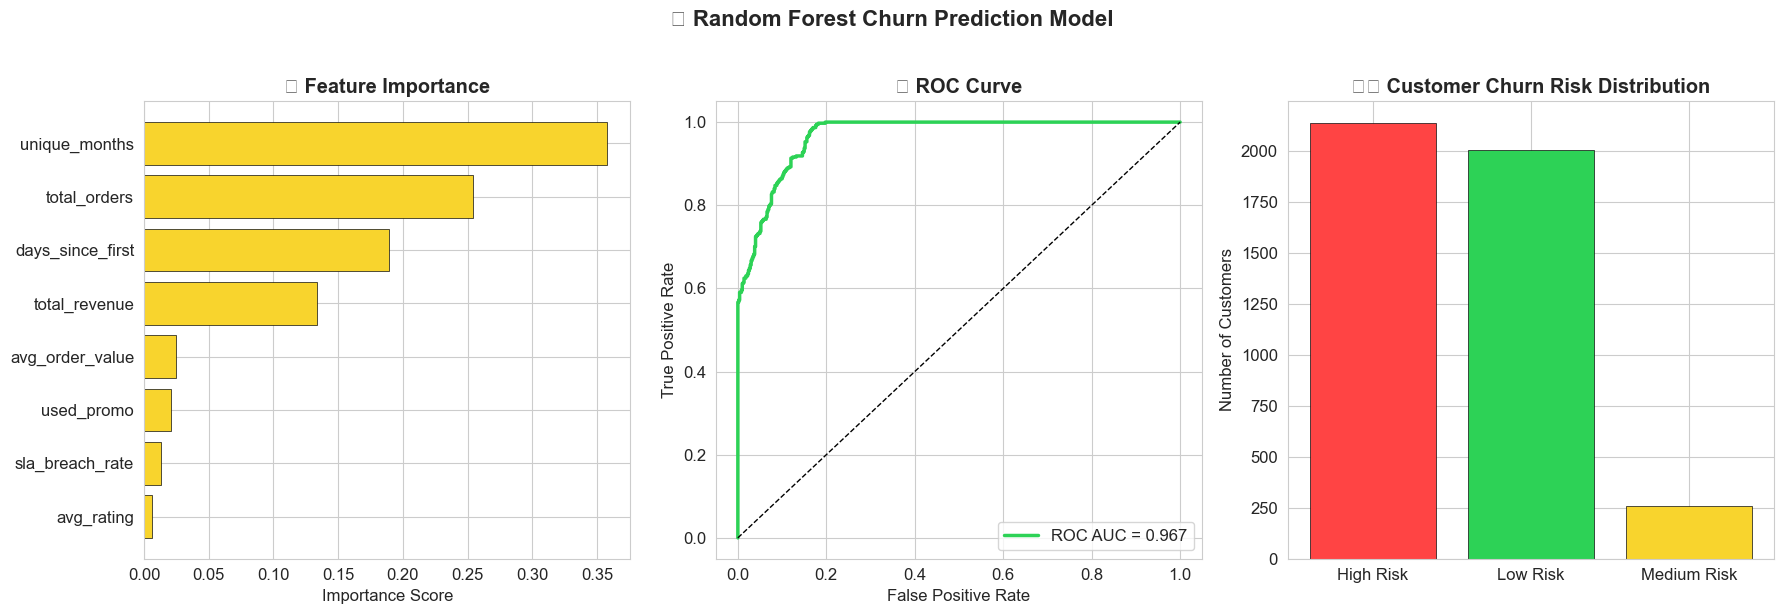


🚨 High Risk  : 2136
⚠️  Medium Risk: 260
✅ Low Risk   : 2006


In [21]:
# ============================================================
# CELL 13: VISUALIZE CHURN MODEL
# ============================================================

# Update churn risk with new model
churn_features['churn_prob'] = rf_model.predict_proba(
    churn_features[feature_cols]
)[:,1]

churn_features['risk_level'] = pd.cut(
    churn_features['churn_prob'],
    bins  = [0, 0.3, 0.6, 1.0],
    labels= ['Low Risk','Medium Risk','High Risk']
)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1 — Feature Importance
feat_imp = pd.Series(
    rf_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=True)

axes[0].barh(feat_imp.index, feat_imp.values,
             color=BLINKIT_YELLOW,
             edgecolor=BLINKIT_BLACK, linewidth=0.5)
axes[0].set_title('🔍 Feature Importance', fontweight='bold')
axes[0].set_xlabel('Importance Score')

# Plot 2 — ROC Curve
from sklearn.metrics import roc_curve, roc_auc_score
roc_auc    = roc_auc_score(y_test, y_pred_prob)
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color=BLINKIT_GREEN,
             linewidth=2.5, label=f'ROC AUC = {roc_auc:.3f}')
axes[1].plot([0,1],[0,1],'k--', linewidth=1)
axes[1].set_title('📈 ROC Curve', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

# Plot 3 — Risk Distribution
risk_counts = churn_features['risk_level'].value_counts()
colors_risk = {'High Risk': '#FF4444',
               'Medium Risk': BLINKIT_YELLOW,
               'Low Risk': BLINKIT_GREEN}
axes[2].bar(risk_counts.index, risk_counts.values,
            color=[colors_risk.get(x, 'grey')
                   for x in risk_counts.index],
            edgecolor=BLINKIT_BLACK, linewidth=0.5)
axes[2].set_title('⚠️ Customer Churn Risk Distribution',
                  fontweight='bold')
axes[2].set_ylabel('Number of Customers')

plt.suptitle('🎯 Random Forest Churn Prediction Model',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_PATH + '18_churn_prediction.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\n🚨 High Risk  : {(churn_features['risk_level']=='High Risk').sum()}")
print(f"⚠️  Medium Risk: {(churn_features['risk_level']=='Medium Risk').sum()}")
print(f"✅ Low Risk   : {(churn_features['risk_level']=='Low Risk').sum()}")

In [ ]:
## 💡 ML Model 3 — Random Forest Churn Prediction
##- Model accuracy: 90%, ROC-AUC: 0.967 — excellent!
#- Catches 99% of actual churners (recall)
#- 2,136 customers at HIGH churn risk right now!
#- Top churn signal: unique_months (consistency > spend)
#- **Immediate Actions:**
#  1. Export 2,136 high-risk customers → marketing team
#  2. Win-back campaign: personalised offer in 24 hours
#  3. Monitor 260 medium-risk — prevent escalation
#  4. SLA breach_rate signal → fix delivery = reduce churn!